<a href="https://colab.research.google.com/github/NehaMusale11/Machine-Vision/blob/main/Practical_no_05_MachineV_CM23057.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle

In [2]:
from google.colab import files
files.upload()

{}

In [3]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)

!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [4]:
!kaggle datasets download -d ashwingupta3012/human-faces

Dataset URL: https://www.kaggle.com/datasets/ashwingupta3012/human-faces
License(s): CC0-1.0
100% 1.82G/1.82G [01:24<00:00, 23.0MB/s]



In [5]:
import zipfile

with zipfile.ZipFile("human-faces.zip", 'r') as zip_ref:
    zip_ref.extractall("human_faces")

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [6]:
import cv2
import os
import matplotlib.pyplot as plt

In [7]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_eye.xml"
)

In [8]:
image_list = []

for root, dirs, files in os.walk("human_faces"):
    for file in files:
        if file.endswith((".jpg", ".png", ".jpeg")):
            image_list.append(os.path.join(root, file))

print("Total Images:", len(image_list))

Total Images: 7201


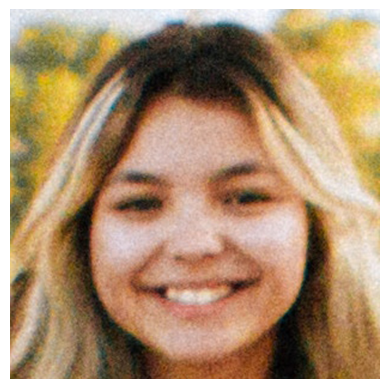

In [9]:
image_path = image_list[0]

img = cv2.imread(image_path)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [10]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [11]:
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.2,
    minNeighbors=5,
    minSize=(60,60)
)

print("Faces Detected:", len(faces))

Faces Detected: 1


Face Detection Results
Faces Detected : 1
Eyes Detected  : 0


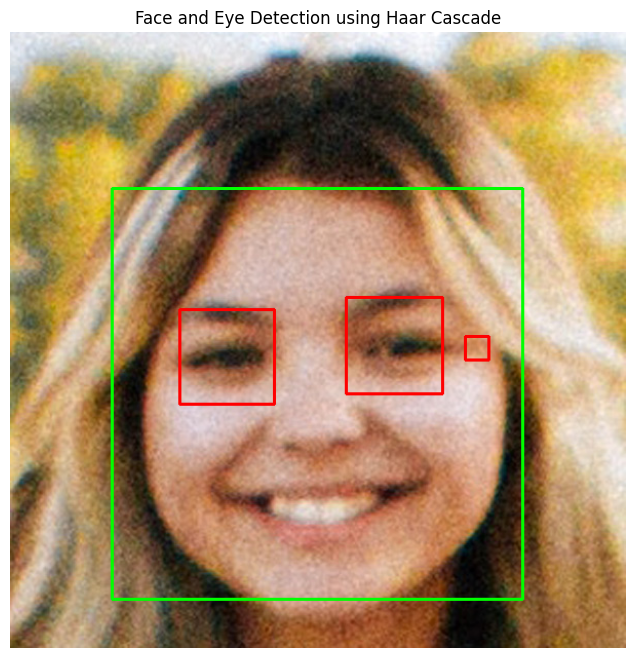

In [17]:
# -------------------------------
# Face and Eye Detection
# -------------------------------

eye_count = 0

for (x, y, w, h) in faces:

    # Draw rectangle around face
    cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (0, 255, 0), 2)

    # Face Region of Interest (ROI)
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = img_rgb[y:y+h, x:x+w]

    # Search only in upper half of face
    upper_gray = roi_gray[:h//2, :]
    upper_color = roi_color[:h//2, :]

    # Detect eyes
    eyes = eye_cascade.detectMultiScale(
        upper_gray,
        scaleFactor=1.1,
        minNeighbors=10,
        minSize=(25, 25),
        maxSize=(80, 80)
    )

    # Keep only the two largest detections
    eyes = sorted(eyes, key=lambda e: e[2] * e[3], reverse=True)[:2]

    eye_count += len(eyes)

    # Draw eye rectangles
    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(
            upper_color,
            (ex, ey),
            (ex + ew, ey + eh),
            (255, 0, 0),
            2
        )

# Display total eyes detected
print("=" * 40)
print("Face Detection Results")
print("=" * 40)
print("Faces Detected :", len(faces))
print("Eyes Detected  :", eye_count)
print("=" * 40)

# Display final image
plt.figure(figsize=(8, 8))
plt.imshow(img_rgb)
plt.title("Face and Eye Detection using Haar Cascade")
plt.axis("off")
plt.show()

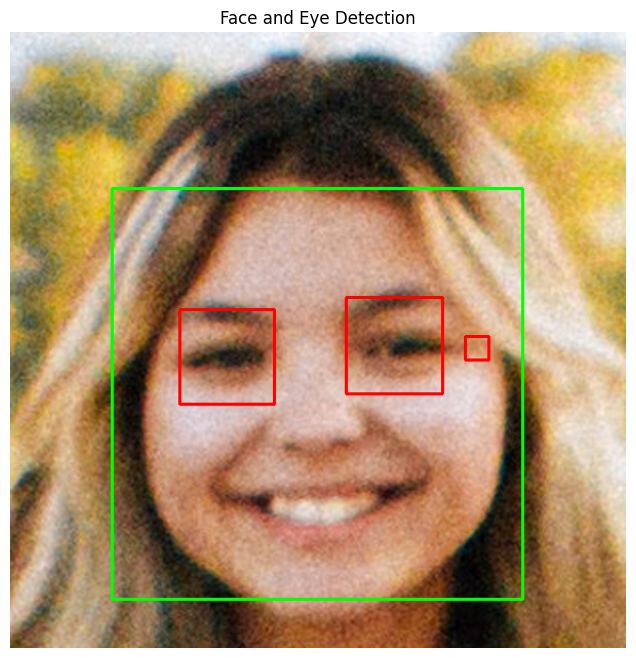

In [13]:
plt.figure(figsize=(8,8))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Face and Eye Detection")
plt.show()

In [14]:
actual_faces = int(input("Enter Actual Number of Faces: "))
actual_eyes = int(input("Enter Actual Number of Eyes: "))

face_accuracy = (min(len(faces), actual_faces)/actual_faces)*100

eye_accuracy = (min(eye_count, actual_eyes)/actual_eyes)*100

print("Face Detection Accuracy = {:.2f}%".format(face_accuracy))

print("Eye Detection Accuracy = {:.2f}%".format(eye_accuracy))

Enter Actual Number of Faces: 1
Enter Actual Number of Eyes: 2
Face Detection Accuracy = 100.00%
Eye Detection Accuracy = 100.00%


In [18]:
lighting = ["Bright", "Normal", "Low"]

results = []

for light in lighting:

    print("\nLighting Condition:", light)

    actual_faces = int(input("Actual Faces: "))
    detected_faces = int(input("Detected Faces: "))

    actual_eyes = int(input("Actual Eyes: "))
    detected_eyes = int(input("Detected Eyes: "))

    face_acc = (min(actual_faces, detected_faces)/actual_faces)*100

    eye_acc = (min(actual_eyes, detected_eyes)/actual_eyes)*100

    results.append([light, detected_faces, detected_eyes, face_acc, eye_acc])

print("\nResult Table")

for r in results:
    print(r)


Lighting Condition: Bright
Actual Faces: 1
Detected Faces: 1
Actual Eyes: 2
Detected Eyes: 2

Lighting Condition: Normal
Actual Faces: 1
Detected Faces: 1
Actual Eyes: 2
Detected Eyes: 2

Lighting Condition: Low
Actual Faces: 1
Detected Faces: 1
Actual Eyes: 2
Detected Eyes: 2

Result Table
['Bright', 1, 2, 100.0, 100.0]
['Normal', 1, 2, 100.0, 100.0]
['Low', 1, 2, 100.0, 100.0]
